In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
A = np.array([
    [0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Node 1
    [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Node 2
    [1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # Node 3
    [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Node 4
    [0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Node 5
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],  # Node 6
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0],  # Node 7
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],  # Node 8
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],  # Node 9
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],  # Node 10
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # Node 11
    [0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0],  # Node 12
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],  # Node 13
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0]   # Node 14
])
A

array([[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0]])

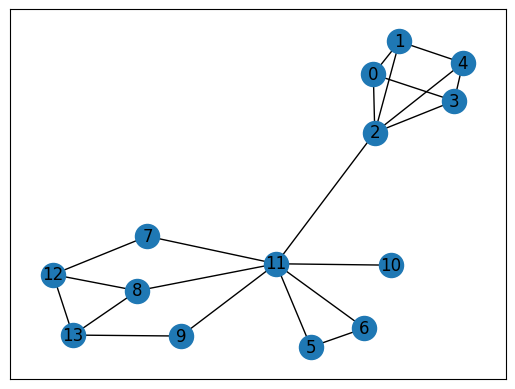

In [2]:
G = nx.from_numpy_array(A)
nx.draw_networkx(G)

In [3]:
mu_l = nx.average_shortest_path_length(G)
print(mu_l)
print(np.log2(G.number_of_nodes()))

2.2967032967032965
3.807354922057604


We should try to run this on few different graph models.

In [4]:
import matplotlib.pyplot as plt


sizes = [10, 20, 40, 80, 160, 320, 740, 1480, 2960, 5920, 11840]
path_l_ws = []
path_l_er = []
path_l_ba = []
log_n_vals = np.log2(sizes)

for size in sizes:
    k=6

    ws = nx.watts_strogatz_graph(size, k, 0.1)
    path_l_ws.append(nx.average_shortest_path_length(ws))

    er = nx.erdos_renyi_graph(size, np.log(size) / size + 0.1)    # p > ln(n)/n highly likely that it is connected
    if nx.is_connected(er):  # Ensure connectivity
        path_l_er.append(nx.average_shortest_path_length(er))
    else:
        path_l_er.append(float('nan'))  # Skip disconnected graphs
    
    ba = nx.barabasi_albert_graph(size, k // 2)
    path_l_ba.append(nx.average_shortest_path_length(ba))

print(path_l_ws)
print(path_l_er)
print(path_l_ba)
print(log_n_vals)



[1.3333333333333333, 1.8894736842105264, 2.6487179487179486, 3.518354430379747, 4.214937106918239, 5.205289968652037, 5.8282266027868195, 6.589784916762604, 7.442096261520053, 8.08659401926001, 8.889181227642036]
[1.8444444444444446, 1.8736842105263158, 2.008974358974359, 1.959493670886076, 1.9188679245283018, 1.8884992163009404, 1.8917529166514282, 1.8952360067978729, 1.8972463761497218, 1.898501276238225, 1.8992775252657843]
[1.5333333333333334, 1.8578947368421053, 2.1256410256410256, 2.479113924050633, 2.826808176100629, 3.0413401253918497, 3.379965621914201, 3.599564168631106, 3.8769866097933012, 4.0884543819034445, 4.3413912703775654]
[ 3.32192809  4.32192809  5.32192809  6.32192809  7.32192809  8.32192809
  9.53138146 10.53138146 11.53138146 12.53138146 13.53138146]


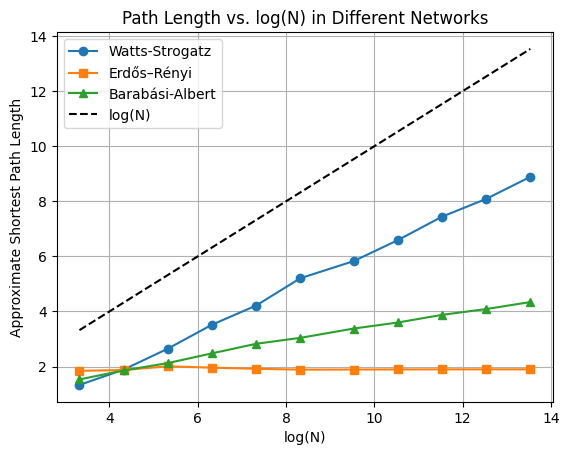

In [5]:
plt.plot(log_n_vals, path_l_ws, 'o-', label='Watts-Strogatz')
plt.plot(log_n_vals, path_l_er, 's-', label='Erdős–Rényi')
plt.plot(log_n_vals, path_l_ba, '^-', label='Barabási-Albert')
plt.plot(log_n_vals, log_n_vals, 'k--', label='log(N)')

plt.xlabel('log(N)')
plt.ylabel('Approximate Shortest Path Length')
plt.title('Path Length vs. log(N) in Different Networks')
plt.legend()
plt.grid()
plt.show()

**Degree distribution of BA graph**

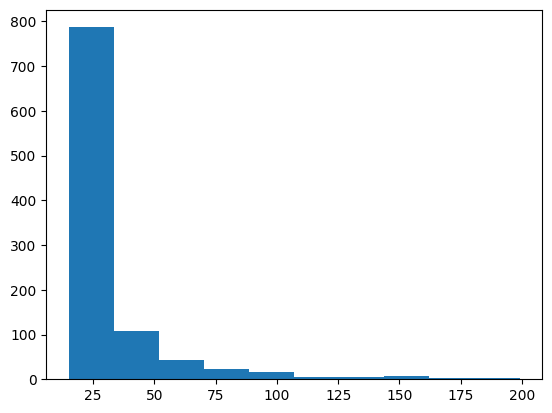

In [11]:
ba = nx.barabasi_albert_graph(n=1000, m=15)
deg_view_ba = nx.degree(ba)
deg_vals = dict(deg_view_ba).values()
plt.hist(deg_vals)
# plt.xticks(range(0, max(deg_vals)+4))
plt.show()

15 199


Text(0, 0.5, 'Number of nodes with Degree')

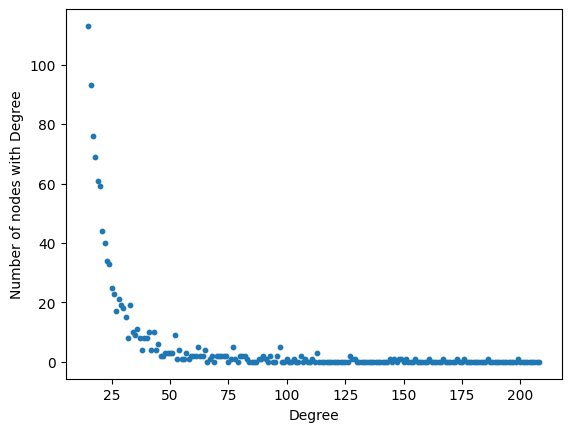

In [12]:
min_deg = min(deg_vals)
max_deg = max(deg_vals)
print(min_deg, max_deg)
x_vals = np.arange(min_deg, max_deg + 10)
y_vals = [list(deg_vals).count(i) for i in x_vals]
marker_size = 10
plt.scatter(x_vals, y_vals, s=marker_size)
plt.xlabel("Degree")
plt.ylabel("Number of nodes with Degree")

Let's look at log-log plot 

15 199
1000


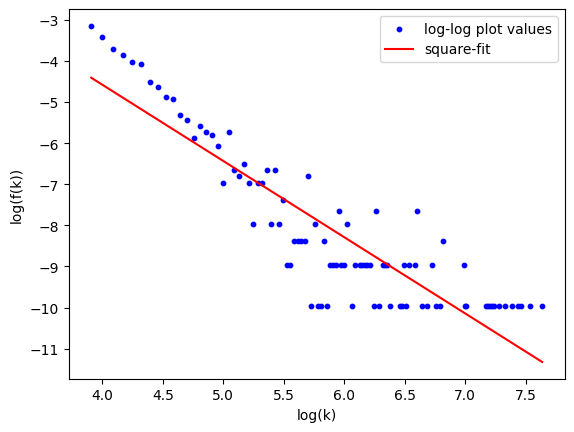

In [13]:
min_deg = min(deg_vals)
max_deg = max(deg_vals)
print(min_deg, max_deg)
n = ba.number_of_nodes()
print(n)

x_vals = np.sort(np.unique(list(deg_vals)))
x_vals
y_vals = [list(deg_vals).count(i)/n for i in x_vals] # remember to divide this by n to get the probability

marker_size = 10

y_log_vals = np.log2(y_vals)
y_log_vals
x_log_vals = np.log2(x_vals)
plt.scatter(x_log_vals, y_log_vals, c='blue', s=marker_size, label='log-log plot values')

m, b = np.polyfit(x_log_vals, y_log_vals, 1)

plt.plot(x_log_vals, m*x_log_vals + b, label='square-fit', c='red')
plt.xlabel("log(k)")
plt.ylabel("log(f(k))")
plt.legend()

In [14]:
predicted = m*x_log_vals + b
SS_res = np.sum((y_log_vals - predicted) ** 2)  # Residual sum of squares
SS_tot = np.sum((y_log_vals - np.mean(y_log_vals)) ** 2)  # Total sum of squares
R2 = 1 - (SS_res / SS_tot)
R2

np.float64(0.796360205212837)

**Let's look at the cumalative degree distribution**

last value -4.440892098500626e-16 True


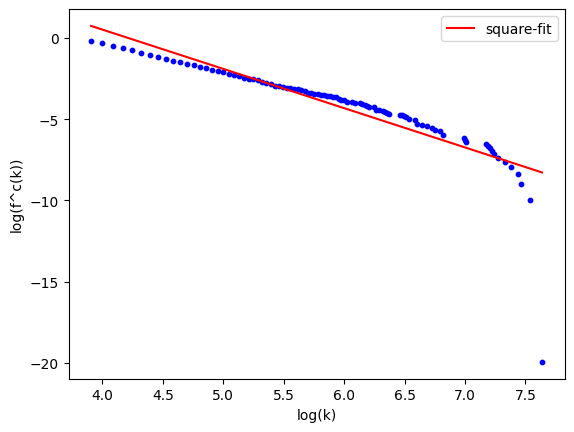

In [15]:
cuma_f_k = np.cumsum(y_vals)

f_c_k = 1 - cuma_f_k

print(f"last value {f_c_k[-1]} {f_c_k[-1] <0}") # this could happen because of float point errors

# manually correcting the last non-zero value to a small non-zero value
f_c_k[-1] = 1e-6
log_f_c_k = np.log2(f_c_k)
plt.scatter(x_log_vals, log_f_c_k, s=marker_size, c='blue')

m_1, b_1 = np.polyfit(x_log_vals, log_f_c_k, 1)

plt.plot(x_log_vals, m_1*x_log_vals + b_1, label='square-fit', c='red')
plt.xlabel("log(k)")
plt.ylabel("log(f^c(k))")
plt.legend()

In [16]:
predicted = m_1*x_log_vals + b_1
SS_res = np.sum((log_f_c_k - predicted) ** 2)  # Residual sum of squares
SS_tot = np.sum((log_f_c_k - np.mean(log_f_c_k)) ** 2)  # Total sum of squares
R2 = 1 - (SS_res / SS_tot)
R2

np.float64(0.743584295829909)

Average clustering coefficient of nodes with degree k

**ER graph**

Text(0, 0.5, 'Number of nodes with Degree')

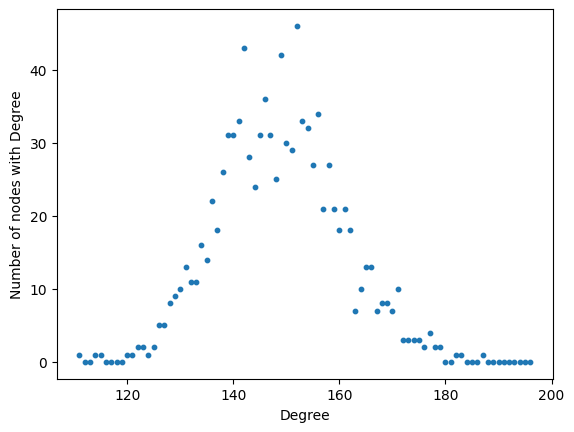

In [17]:
er = nx.erdos_renyi_graph(n=1000, p =0.15)
deg_view_er = nx.degree(er)
deg_vals_er = dict(deg_view_er).values()

min_deg_er = min(deg_vals_er)
max_deg_er = max(deg_vals_er)

x_vals_er = np.arange(min_deg_er, max_deg_er + 10)
y_vals_er = [list(deg_vals_er).count(i) for i in x_vals_er]
marker_size_er = 10
plt.scatter(x_vals_er, y_vals_er, s=marker_size_er)
plt.xlabel("Degree")
plt.ylabel("Number of nodes with Degree")

100


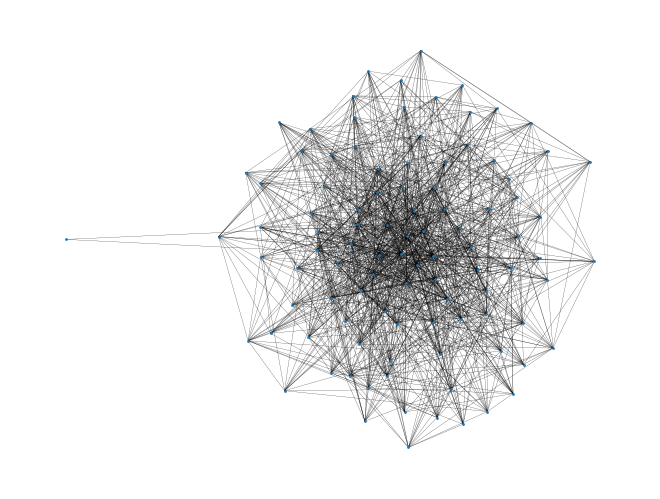

In [18]:
ba_2 = nx.barabasi_albert_graph(n=100, m=15)

nx.draw(ba_2, node_size=1, width=0.15)
print(ba_2.number_of_nodes())

1000


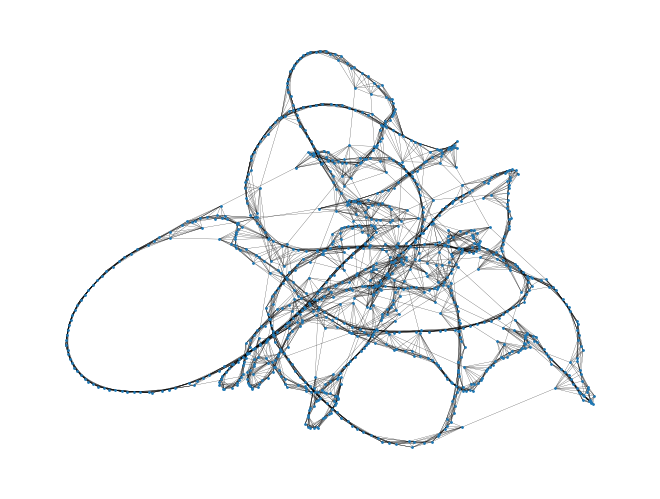

In [19]:
ws_2 = nx.watts_strogatz_graph(n=1000, k=10, p=0.015)

nx.draw(ws_2, node_size=1, width=0.15)
print(ws_2.number_of_nodes())

Text(0, 0.5, 'Number of nodes with Degree')

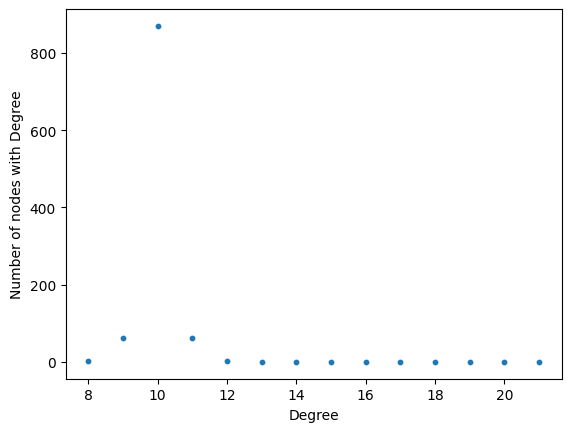

In [20]:
deg_view_ws_2 = nx.degree(ws_2)
deg_vals_ws_2 = dict(deg_view_ws_2).values()

min_deg_ws_2 = min(deg_vals_ws_2)
max_deg_ws_2 = max(deg_vals_ws_2)

x_vals_ws_2 = np.arange(min_deg_ws_2, max_deg_ws_2 + 10)
y_vals_ws_2 = [list(deg_vals_ws_2).count(i) for i in x_vals_ws_2]
marker_size_ws_2 = 10
plt.scatter(x_vals_ws_2, y_vals_ws_2, s=marker_size_ws_2)
plt.xlabel("Degree")
plt.ylabel("Number of nodes with Degree")

**Plot of average clustering coeffs of nodes with degree k**

[ 8  9 10 11 12]
[0.6190476190476191, 0.6406810035842294, 0.6468710089399744, 0.5269794721407625, 0.4444444444444444]


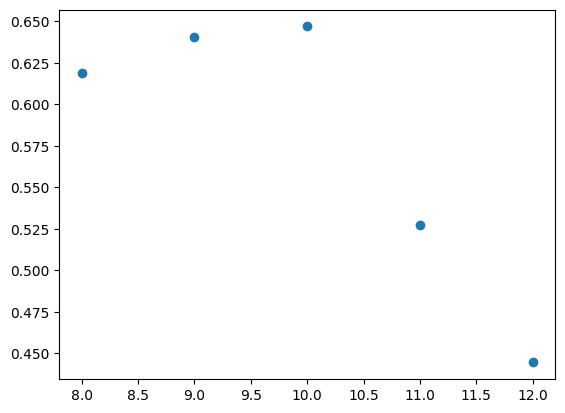

In [21]:
deg_vals_ws_2
unique_deg_vals_ws_2 = np.unique(list(deg_vals_ws_2))
unique_deg_vals_ws_2
nodes_with_deg_k = [[node for node, deg in ws_2.degree() if deg == k] for k in unique_deg_vals_ws_2]
nodes_with_deg_k
avg_clust_coefs_with_deg_k = [nx.average_clustering(ws_2, nodes) for nodes in nodes_with_deg_k]
avg_clust_coefs_with_deg_k
print(unique_deg_vals_ws_2)
print(avg_clust_coefs_with_deg_k)
plt.scatter(unique_deg_vals_ws_2, avg_clust_coefs_with_deg_k)